# Gaussian Process Emulation of the 21-cm Power Spectrum

In this notebook we build a Gaussian Process (GP) emulator for the 21-cm power spectrum, using realisations generated by the `zeus21` model. The emulator learns to predict the power spectrum $\Delta^2(k)$ as a function of four input parameters:

| Parameter | Symbol | Description |
|-----------|--------|-------------|
| X-ray luminosity | $L_{40,\mathrm{X}}$ | X-ray luminosity in units of $10^{40}\ \mathrm{erg\,s^{-1}\,M_\odot^{-1}\,yr}$ |
| Escape fraction | $f_{\mathrm{esc},10}$ | Ionising photon escape fraction at $10^{10}\ M_\odot$ |
| Star formation efficiency | $\epsilon_\star$ | Star formation efficiency at the peak halo mass |
| Reduced Hubble constant | $h_0$ | $H_0 / (100\ \mathrm{km\,s^{-1}\,Mpc^{-1}})$ |

Rather than training a separate GP for every $k$-mode, we first compress the simulations with **Principal Component Analysis (PCA)** and then train one GP per principal component. This makes the problem tractable while preserving almost all of the variance in the training set.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel


## 1. Loading the Simulations

We load 2500 `zeus21` power spectrum realisations from disk. Each simulation file contains:
- `k` — the wavenumber array (shared across all simulations)
- `power` — the 21-cm power spectrum $\Delta^2(k)$ for that realisation
- `astro_params` — the astrophysical parameters ($L_{40,\mathrm{X}}$, $f_{\mathrm{esc},10}$, $\epsilon_\star$)
- `cosmo_params` — the cosmological parameters ($h_0$)

The four parameters are collected into a design matrix $\mathbf{X} \in \mathbb{R}^{2500 \times 4}$. Because the parameters span several orders of magnitude, we work in **log-space** throughout — this regularises the input space and typically leads to smoother GP covariance functions.

In [2]:
simulations = [np.load(f"../simulations/sample_{i:06d}.npz",
                       allow_pickle=True) for i in range(2500)]

k = simulations[0]["k"]
powers = np.array([sim["power"] for sim in simulations])
astro_params = np.array([list(sim["astro_params"].item().values()) 
                         for sim in simulations])
cosmo_params = np.array([list(sim["cosmo_params"].item().values()) 
                         for sim in simulations])
param_names = list(simulations[0]["astro_params"].item().keys()) + \
              list(simulations[0]["cosmo_params"].item().keys())

X = np.hstack([astro_params, cosmo_params])
X = np.log10(X)  # log-transform the parameters
X.shape

(2500, 4)

## 2. Dimensionality Reduction with PCA

The power spectrum is evaluated at many $k$-modes, so the output space is high-dimensional. Training one GP per output dimension would be expensive and unnecessary — neighbouring $k$-modes are strongly correlated.

**Principal Component Analysis (PCA)** exploits this structure. We decompose the covariance matrix of the training powers:

$$\mathbf{C} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^\top$$

and project onto the leading eigenvectors (principal components). The cumulative explained variance plot tells us how many components we need. We retain just enough to capture **99.99%** of the total variance — in practice only a handful of components are required.

The PCA scores are then standardised (zero mean, unit variance) before being passed to the GPs, which helps the optimiser find good hyperparameters.

Number of components to retain 99.99% variance: 3


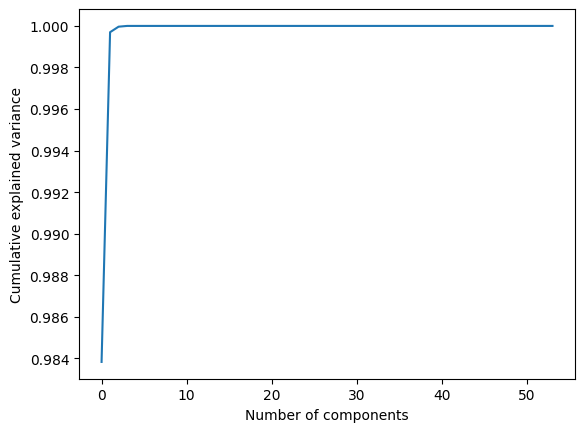

In [3]:
from sklearn.model_selection import train_test_split

train_powers, test_powers, train_X, test_X = train_test_split(powers, X, test_size=0.2)

cov = np.cov(train_powers.T)

eigenvalues, eigenvectors = np.linalg.eig(cov)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

plt.plot(cumulative_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.savefig('pca-variance.png', dpi=300, bbox_inches='tight')

n_components = np.where(cumulative_variance >= 0.9999)[0][0] + 1
print(f'Number of components to retain 99.99% variance: {n_components}')

# project the data onto the top n_components eigenvectors
train_pca = train_powers @ eigenvectors[:, :n_components]
test_pca = test_powers @ eigenvectors[:, :n_components]

norm_mean = np.mean(train_pca, axis=0)
norm_std = np.std(train_pca, axis=0)

train_pca = (train_pca - norm_mean) / norm_std
test_pca = (test_pca - norm_mean) / norm_std


## 3. Training the Gaussian Processes

We train one GP per principal component. Each GP models the mapping from the four input parameters to a single PCA score:

$$f_i(\boldsymbol{\theta}) \sim \mathcal{GP}\!\left(\mu_i(\boldsymbol{\theta}),\, k_i(\boldsymbol{\theta}, \boldsymbol{\theta}')\right)$$

The kernel is a **constant amplitude × RBF (squared-exponential)**:

$$k(\boldsymbol{\theta}, \boldsymbol{\theta}') = \sigma_f^2 \exp\!\left(-\frac{1}{2} \sum_{d=1}^{4} \frac{(\theta_d - \theta_d')^2}{\ell_d^2}\right)$$

Each dimension gets its own length-scale $\ell_d$, allowing the GP to learn how sensitive the power spectrum is to each parameter independently. Hyperparameters are optimised by maximising the **log marginal likelihood**, restarted from multiple initialisations to avoid local optima.

In [4]:
kernel = ConstantKernel(1.0) * RBF(length_scale=[1.0]*4) 

gps = []
for i in range(n_components):
    gp = GPR(
        kernel=kernel,
        alpha=1e-6,
        n_restarts_optimizer=5,
        random_state=i,
    )
    gp.fit(train_X, train_pca[:, i])
    gps.append(gp)
    print(f"GP {i+1} trained | log-marginal-likelihood = {gp.log_marginal_likelihood_value_:.2f}")



GP 1 trained | log-marginal-likelihood = 9930.55
GP 2 trained | log-marginal-likelihood = 8835.37
GP 3 trained | log-marginal-likelihood = 8287.41


## 4. Predicting and Reconstructing the Power Spectrum

To make a prediction at new parameters $\boldsymbol{\theta}_*$:

1. Each GP returns a **mean** and **standard deviation** in PCA-score space.
2. The scores are un-normalised (multiply by $\sigma$, add $\mu$).
3. The reconstructed power spectrum is obtained by projecting back through the PCA eigenvectors:

$$\widehat{\Delta^2}(k) = \sum_{i=1}^{n_\mathrm{PC}} \hat{s}_i\, \mathbf{v}_i(k)$$

where $\hat{s}_i$ is the predicted score for component $i$ and $\mathbf{v}_i$ is the corresponding eigenvector. The uncertainty is propagated in the same way (assuming the components are independent).

Below we compare the emulator predictions against held-out test simulations for five randomly chosen samples.

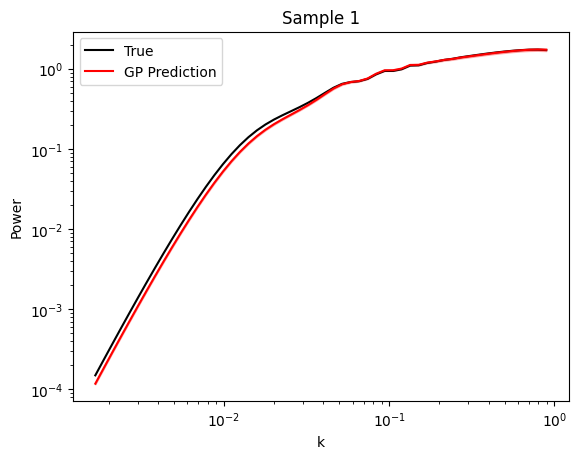

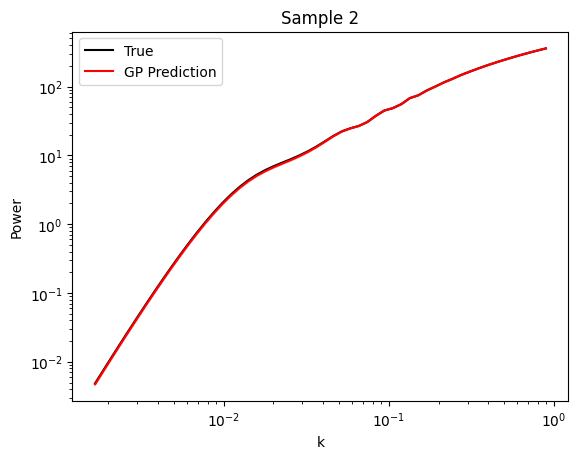

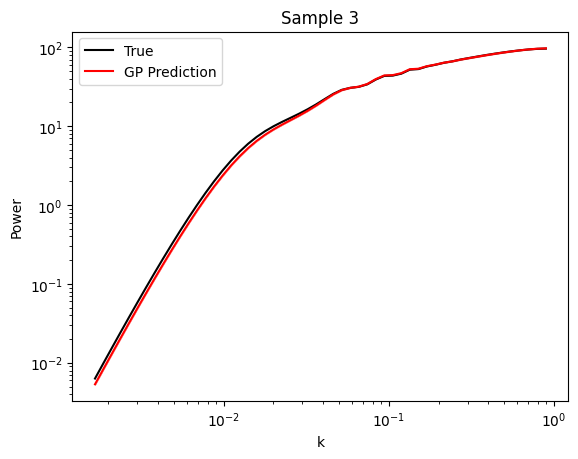

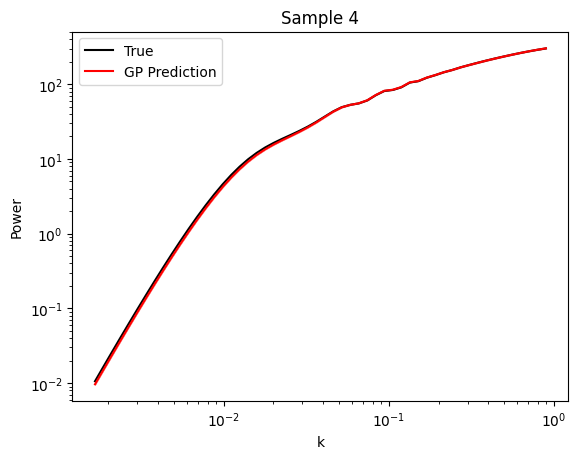

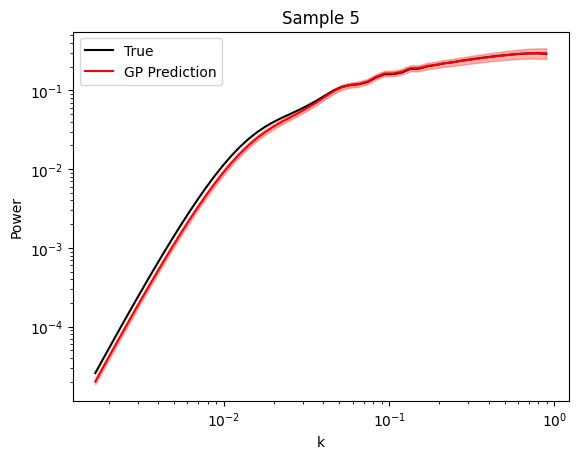

In [5]:
def predict(gps, X):
    n_samples = X.shape[0]
    n_components = len(gps)
    mean = np.zeros((n_samples, n_components))
    std = np.zeros((n_samples, n_components))
    
    for i, gp in enumerate(gps):
        mean[:, i], std[:, i] = gp.predict(X, return_std=True)
    
    return mean, std

test_mean, test_std = predict(gps, test_X)
test_mean = test_mean * norm_std + norm_mean
test_std = test_std * norm_std

reconstructed_mean = test_mean @ eigenvectors[:, :n_components].T 
reconstruction_std = np.sqrt(test_std**2 @ eigenvectors[:, :n_components].T**2)

for i in range(5):
    plt.plot(k, test_powers[i], label='True', color='k')
    plt.plot(k, reconstructed_mean[i], label='GP Prediction', color='r')
    plt.fill_between(k, reconstructed_mean[i] - reconstruction_std[i], 
                     reconstructed_mean[i] + reconstruction_std[i], color='r', alpha=0.3)
    plt.xlabel('k')
    plt.ylabel('Power')
    plt.loglog()
    plt.legend()
    plt.title(f'Sample {i+1}')
    plt.savefig(f'gp_prediction_{i}.png', dpi=300, bbox_inches='tight')
    plt.show()

## 5. Emulator Accuracy

We quantify accuracy with the **mean fractional residual** per test sample:

$$\epsilon_i = \frac{1}{N_k} \sum_k \frac{|\Delta^2_\mathrm{true}(k) - \widehat{\Delta^2}(k)|}{|\Delta^2_\mathrm{true}(k)|}$$

This metric is dimensionless and easy to interpret: $\epsilon = 0.01$ means 1% error on average across $k$-modes. It is the same metric used in the neural network emulator notebook, so the two approaches can be compared directly.

We also show the **pull** — the residual normalised by the GP predictive uncertainty — which is a GP-specific diagnostic. A well-calibrated GP should have pulls of order unity: much larger values indicate a poor fit, while much smaller values indicate an over-conservative uncertainty estimate.

Mean percentage error:      14.12 %
95th percentile:            30.82 %


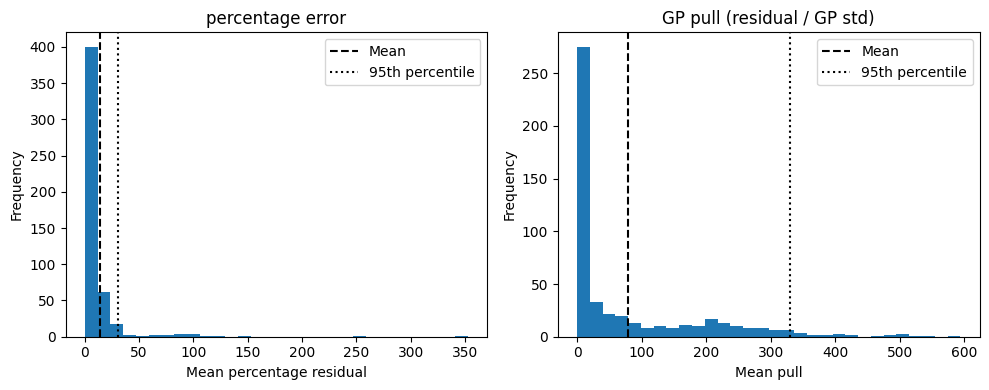

In [6]:
percentage_errors = np.array([
    100*np.mean(np.abs(test_powers[i] - reconstructed_mean[i]) / np.abs(test_powers[i]))
    for i in range(len(test_powers))
])

print(f'Mean percentage error:      {np.mean(percentage_errors):.2f} %')
print(f'95th percentile:            {np.quantile(percentage_errors, 0.95):.2f} %')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(percentage_errors, bins=30)
axes[0].axvline(np.mean(percentage_errors), label='Mean', ls='--', c='k')
axes[0].axvline(np.quantile(percentage_errors, 0.95), label='95th percentile', ls=':', c='k')
axes[0].set_xlabel('Mean percentage residual')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_title('percentage error')

pulls = np.array([
    np.mean(np.abs(test_powers[i] - reconstructed_mean[i]) / np.abs(reconstruction_std[i]))
    for i in range(len(test_powers))
])

axes[1].hist(pulls, bins=30)
axes[1].axvline(np.mean(pulls), label='Mean', ls='--', c='k')
axes[1].axvline(np.quantile(pulls, 0.95), label='95th percentile', ls=':', c='k')
axes[1].set_xlabel('Mean pull')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_title('GP pull (residual / GP std)')

plt.tight_layout()
plt.savefig('error_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. GP Uncertainty Map in Parameter Space

One of the key advantages of a GP emulator is that it provides **uncertainty estimates** — not just predictions. The GP predictive variance is large where training data are sparse and small where they are dense.

Here we visualise the GP standard deviation $\sigma[\Delta^2]$ as a function of $\log_{10} L_{40,\mathrm{X}}$ and $\log_{10} f_{\mathrm{esc},10}$, holding the remaining parameters fixed at their median values. The overlaid scatter points show the training sample locations.

This map is useful for **experimental design**: regions with large uncertainty are where new simulations would most reduce the emulator error.

(30, 30, 3)

Saved figure to gp_emulator.png


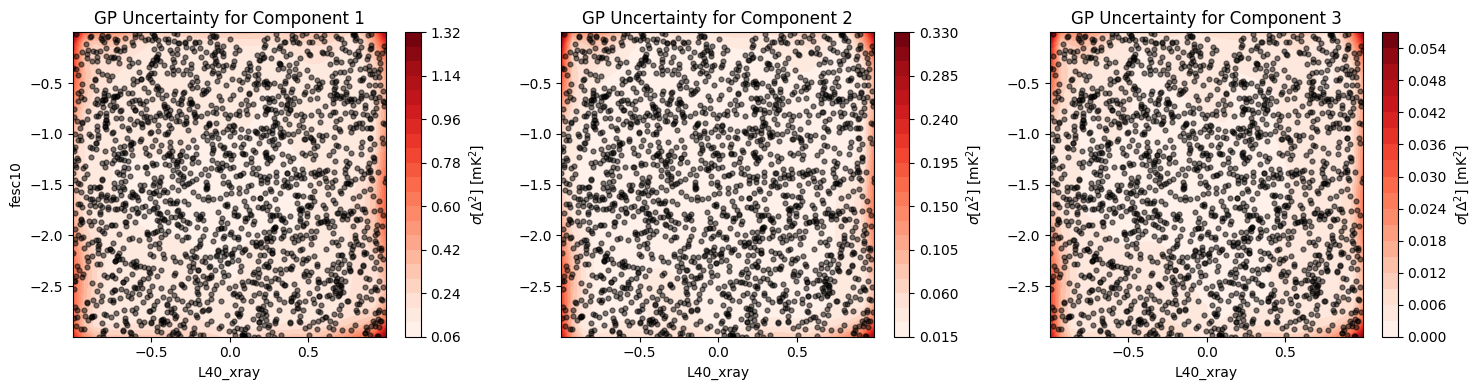

In [7]:
n_grid   = 30
P1_grid  = np.linspace(X[:, 0].min(), X[:, 0].max(), n_grid)
P2_grid = np.linspace(X[:, 1].min(), X[:, 1].max(), n_grid)
P3_grid = np.linspace(X[:, 2].min(), X[:, 2].max(), n_grid)
P4_grid = np.linspace(X[:, 3].min(), X[:, 3].max(), n_grid)
P1, P2 = np.meshgrid(P1_grid, P2_grid)

sigma_map = np.zeros((n_grid, n_grid, n_components))
for i in range(n_grid):
    for j in range(n_grid):
        mean, std = predict(gps, np.array([[P1[i,j], P2[i,j], P3_grid[n_grid//2], P4_grid[n_grid//2]]]))
        std = std * norm_std 
        sigma_map[i, j, :] = std

print(sigma_map.shape)
fig, axes = plt.subplots(1, n_components, figsize=(5*n_components, 4))

for i in range(n_components):
    ax = axes[i]
    im = ax.contourf(P1, P2, sigma_map[:, :, i], levels=20, cmap="Reds")
    plt.colorbar(im, ax=ax, label=r"$\sigma[\Delta^2]$ [mK$^2$]")
    if i == 0:
        ax.set_ylabel(param_names[1])
    ax.set_xlabel(param_names[0])

    # Overlay training points
    ax.scatter(train_X[:,0], train_X[:,1],
            s=12, c="k", alpha=0.5, zorder=5, label="Training points")
    ax.set_title(f"GP Uncertainty for Component {i+1}")

plt.tight_layout()
plt.savefig("gp_emulator_map_error.png", dpi=150, bbox_inches="tight")
print("\nSaved figure to gp_emulator.png")

## 7. Visualising the Kernel

The kernel function $k(\boldsymbol{\theta}, \boldsymbol{\theta}^*)$ measures how correlated two points in parameter space are expected to be. Evaluating it over the $(\log L_{40,\mathrm{X}},\ \log f_{\mathrm{esc},10})$ plane at a fixed reference point $\boldsymbol{\theta}^*$ (the test-set mean) gives a direct picture of the **effective range** of the emulator.

A narrow kernel means the GP relies heavily on nearby training points; a broad kernel means it can extrapolate further. Comparing kernels across principal components reveals which components are most sensitive to the input parameters.

[[-0.02753841 -1.5623176  -1.5378928  -0.12976968]]
Grid shape: (900, 4)
(900, 1)
(900, 1)
(900, 1)


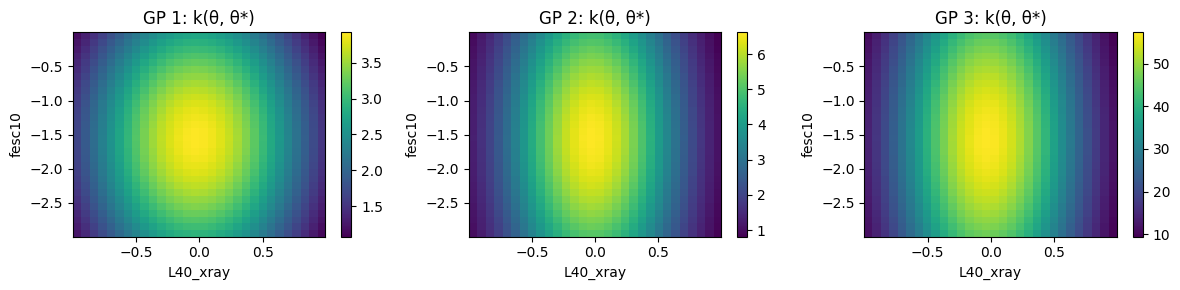

In [8]:
theta_ref = test_X.mean(axis=0).reshape(1, -1)  # centre of grid
print(theta_ref)

fig, axes = plt.subplots(1, len(gps), figsize=(4*len(gps), 3))

grid = np.column_stack([
    P1.ravel(),                          # (n_pts,)
    P2.ravel(),                          # (n_pts,)
    theta_ref[0, 2]*np.ones_like(P1.ravel()),     # (n_pts,)
    theta_ref[0, 3]*np.ones_like(P1.ravel())      # (n_pts,)
])  # shape (n_pts, 4) ✓


print("Grid shape:", grid.shape)
for i, gp in enumerate(gps):
    K = gp.kernel_(grid, theta_ref)
    print(K.shape)
    im = axes[i].imshow(K.reshape(n_grid, n_grid), 
                        cmap='viridis', aspect='auto',
                        origin='lower',
                        extent=(P1_grid.min(), P1_grid.max(), P2_grid.min(), P2_grid.max()))
    axes[i].set_xlabel(param_names[0])
    axes[i].set_ylabel(param_names[1])
    axes[i].set_title(f'GP {i+1}: k(θ, θ*)')
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()

## 8. Fitted Length-scales and Parameter Sensitivity

The **length-scale** $\ell_d$ for each input dimension, fitted by maximising the log marginal likelihood, tells us how quickly the GP output changes as we vary parameter $d$. A **short** length-scale means the emulator output is very sensitive to that parameter; a **long** length-scale means the output varies slowly and the GP can generalise over a wide range.

Comparing length-scales across parameters gives us a rough **sensitivity analysis** — essentially a GP-based equivalent of varying one parameter at a time — without any additional simulations.

GP 1: {'k1': 1.98**2, 'k2': RBF(length_scale=[0.746, 1.87, 0.537, 508]), 'k1__constant_value': np.float64(3.9202913794917116), 'k1__constant_value_bounds': (1e-05, 100000.0), 'k2__length_scale': array([  0.74581477,   1.87173694,   0.53656086, 508.35851508]), 'k2__length_scale_bounds': (1e-05, 100000.0)}
GP 2: {'k1': 2.57**2, 'k2': RBF(length_scale=[0.54, 2, 0.401, 157]), 'k1__constant_value': np.float64(6.617591330843018), 'k1__constant_value_bounds': (1e-05, 100000.0), 'k2__length_scale': array([  0.54017474,   2.00169417,   0.40078045, 156.90973981]), 'k2__length_scale_bounds': (1e-05, 100000.0)}
GP 3: {'k1': 7.57**2, 'k2': RBF(length_scale=[0.578, 2.26, 0.389, 339]), 'k1__constant_value': np.float64(57.361492102044615), 'k1__constant_value_bounds': (1e-05, 100000.0), 'k2__length_scale': array([  0.57790112,   2.25885114,   0.38882316, 339.32158601]), 'k2__length_scale_bounds': (1e-05, 100000.0)}


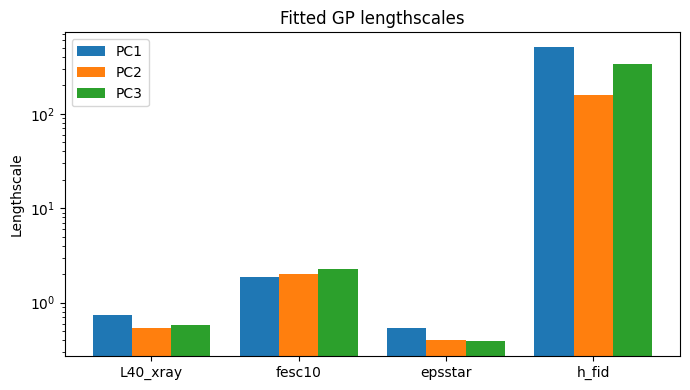

In [9]:
for i, gp in enumerate(gps):
    ls = gp.kernel_.get_params()
    print(f"GP {i+1}: {ls}")

lengthscales = np.array([
    gp.kernel_.get_params()['k2__length_scale']
    for gp in gps
])  # shape (n_components, n_params)

n_params = lengthscales.shape[1]
x = np.arange(n_params)
width = 0.8 / len(gps)

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(len(gps)):
    ax.bar(x + i*width, lengthscales[i], width, label=f'PC{i+1}')

ax.set_xticks(x + width*(len(gps)-1)/2)
ax.set_xticklabels(param_names)
ax.set_ylabel('Lengthscale')
ax.set_yscale('log')   # log scale essential given the 414 outlier
ax.set_title('Fitted GP lengthscales')
ax.legend()
plt.tight_layout()